In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, multilabel_confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import timm
from transformers import ViTImageProcessor, ViTForImageClassification
import warnings
warnings.filterwarnings('ignore')
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit


# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BASE_DIR = "./dataset_5nodes/"
CSV_PATH = os.path.join(BASE_DIR, "labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "images")

# Disease labels for multi-label classification (5 diseases only)
TARGET_LABELS = ['Consolidation', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia']

NUM_CLASSES = len(TARGET_LABELS)
print(f"Number of disease classes: {NUM_CLASSES}")
print(f"Disease labels: {TARGET_LABELS}")

# Training hyperparameters
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
IMAGE_SIZE = 224

Number of disease classes: 5
Disease labels: ['Consolidation', 'Infiltration', 'Mass', 'Nodule', 'Pneumonia']


In [3]:
# ============================================================================
# LOAD AND PREPARE DATA WITH TRAIN/VAL/TEST SPLIT
# ============================================================================

# Load dataset
df = pd.read_csv(CSV_PATH)
df = df[['Path'] + TARGET_LABELS].copy()

print(f"\nTotal samples: {len(df)}")
print(f"Dataset shape: {df.shape}")

# Verify "No Finding" cases
no_finding_count = (df[TARGET_LABELS].sum(axis=1) == 0).sum()
print(f"No Finding samples (all zeros): {no_finding_count}")

# Get labels as numpy array for stratification
y = df[TARGET_LABELS].values

# First split: Train (70%) vs Temp (30%)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(msss.split(df, y))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# Second split: Val (15%) vs Test (15%)
y_temp = temp_df[TARGET_LABELS].values
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(msss2.split(temp_df, y_temp))
val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

print(f"\nTraining samples: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation samples: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test samples: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

# Verify each class is present in all splits
print(f"\nClass distribution verification:")
for label in TARGET_LABELS:
    train_count = train_df[label].sum()
    val_count = val_df[label].sum()
    test_count = test_df[label].sum()
    total = train_count + val_count + test_count
    print(f"{label:20s}: Train={train_count:5d} ({train_count/total*100:5.1f}%), "
          f"Val={val_count:4d} ({val_count/total*100:5.1f}%), "
          f"Test={test_count:4d} ({test_count/total*100:5.1f}%)")


Total samples: 28096
Dataset shape: (28096, 6)
No Finding samples (all zeros): 5000

Training samples: 19667 (70.0%)
Validation samples: 4214 (15.0%)
Test samples: 4215 (15.0%)

Class distribution verification:
Consolidation       : Train= 3137 ( 70.0%), Val= 672 ( 15.0%), Test= 672 ( 15.0%)
Infiltration        : Train= 4018 ( 70.0%), Val= 861 ( 15.0%), Test= 861 ( 15.0%)
Mass                : Train= 3895 ( 70.0%), Val= 834 ( 15.0%), Test= 835 ( 15.0%)
Nodule              : Train= 3944 ( 70.0%), Val= 845 ( 15.0%), Test= 845 ( 15.0%)
Pneumonia           : Train= 4273 ( 70.0%), Val= 916 ( 15.0%), Test= 916 ( 15.0%)


In [4]:
# ============================================================================
# IMPORT CUSTOM DATASET CLASS
# ============================================================================
from dataset_handler import NIHChestXrayDataset

print("NIHChestXrayDataset class imported successfully.")

NIHChestXrayDataset class imported successfully.


In [5]:
# ============================================================================
# DATA AUGMENTATION AND TRANSFORMS (Conservative for CXR)
# ============================================================================

# Training transforms with MINIMAL augmentation (CXR-sensitive)
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),  # Safe for CXR
    transforms.RandomRotation(degrees=5),    # Reduced to ±5° (was 10°)
    # Removed ColorJitter - CXR intensity values are diagnostically important
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Test transforms (identical to validation)
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

In [6]:
# ============================================================================
# CREATE DATASETS AND DATALOADERS
# ============================================================================

# Create datasets
train_dataset = NIHChestXrayDataset(
    train_df, IMAGE_DIR, TARGET_LABELS, transform=train_transforms
)
val_dataset = NIHChestXrayDataset(
    val_df, IMAGE_DIR, TARGET_LABELS, transform=val_transforms
)
test_dataset = NIHChestXrayDataset(
    test_df, IMAGE_DIR, TARGET_LABELS, transform=test_transforms  # Same as val
)

# Create data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4,  # Set to 0 for Windows
    pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,  # Never shuffle test data
    num_workers=4,
    pin_memory=torch.cuda.is_available()
)

print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 615
Number of validation batches: 132
Number of test batches: 132


In [7]:
# ============================================================================
# MODEL DEFINITION
# ============================================================================

class ViTForMultiLabelClassification(nn.Module):
    """Vision Transformer for multi-label classification"""
    
    def __init__(self, num_classes, pretrained=True):
        super(ViTForMultiLabelClassification, self).__init__()
        
        # Load pretrained ViT model using timm
        self.vit = timm.create_model(
            'vit_base_patch16_224',
            pretrained=pretrained,
            num_classes=0  # Remove classification head
        )
        
        # Get the feature dimension
        self.feature_dim = self.vit.num_features
        
        # Custom classification head for multi-label
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        # Extract features
        features = self.vit(x)
        
        # Classification
        logits = self.classifier(features)
        
        return logits

# Initialize model
model = ViTForMultiLabelClassification(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

print(f"\nModel architecture:")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


Model architecture:
Total parameters: 86,194,949
Trainable parameters: 86,194,949


In [8]:
# ============================================================================
# LOSS FUNCTION AND OPTIMIZER
# ============================================================================

# Binary Cross Entropy with Logits Loss (handles multi-label)
criterion = nn.BCEWithLogitsLoss()

# AdamW optimizer
optimizer = optim.AdamW(
    model.parameters(), 
    lr=LEARNING_RATE, 
    weight_decay=WEIGHT_DECAY
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=NUM_EPOCHS
)

In [9]:
# ============================================================================
# TRAINING AND EVALUATION FUNCTIONS
# ============================================================================

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(dataloader, desc='Training')
    for images, labels in pbar:
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        
        # Store predictions and labels
        preds = torch.sigmoid(outputs).detach().cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.cpu().numpy())
        
        pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for images, labels in pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * images.size(0)
            
            # Store predictions and labels
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())
            
            pbar.set_postfix({'loss': loss.item()})
    
    epoch_loss = running_loss / len(dataloader.dataset)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    
    return epoch_loss, all_preds, all_labels

def compute_metrics(labels, predictions, threshold=0.5):
    """Compute evaluation metrics"""
    metrics = {}
    
    # ROC AUC (per class and mean)
    try:
        auc_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:  # Check if both classes present
                auc = roc_auc_score(labels[:, i], predictions[:, i])
                auc_scores.append(auc)
        metrics['auc_mean'] = np.mean(auc_scores) if auc_scores else 0.0
    except:
        metrics['auc_mean'] = 0.0
    
    # Average Precision (per class and mean)
    try:
        ap_scores = []
        for i in range(labels.shape[1]):
            if len(np.unique(labels[:, i])) > 1:
                ap = average_precision_score(labels[:, i], predictions[:, i])
                ap_scores.append(ap)
        metrics['ap_mean'] = np.mean(ap_scores) if ap_scores else 0.0
    except:
        metrics['ap_mean'] = 0.0
    
    # Binary predictions for accuracy
    binary_preds = (predictions >= threshold).astype(int)
    
    # Accuracy
    metrics['accuracy'] = np.mean(binary_preds == labels)
    
    return metrics

In [10]:
# ============================================================================
# TRAINING LOOP
# ============================================================================

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_auc': [],
    'val_auc': [],
    'train_ap': [],
    'val_ap': [],
    'train_acc': [],
    'val_acc': []
}

best_val_auc = 0.0
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 70)
    
    # Train
    train_loss, train_preds, train_labels = train_epoch(
        model, train_loader, criterion, optimizer, device
    )
    train_metrics = compute_metrics(train_labels, train_preds)
    
    # Validate
    val_loss, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, device
    )
    val_metrics = compute_metrics(val_labels, val_preds)
    
    # Update learning rate
    scheduler.step()
    
    # Store history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_metrics['auc_mean'])
    history['val_auc'].append(val_metrics['auc_mean'])
    history['train_ap'].append(train_metrics['ap_mean'])
    history['val_ap'].append(val_metrics['ap_mean'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['val_acc'].append(val_metrics['accuracy'])
    
    # Print metrics
    print(f"\nTrain Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Train AUC: {train_metrics['auc_mean']:.4f} | Val AUC: {val_metrics['auc_mean']:.4f}")
    print(f"Train AP: {train_metrics['ap_mean']:.4f} | Val AP: {val_metrics['ap_mean']:.4f}")
    print(f"Train Acc: {train_metrics['accuracy']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
    
    # Save best model
    if val_metrics['auc_mean'] > best_val_auc:
        best_val_auc = val_metrics['auc_mean']
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_auc': best_val_auc,
        }, 'best_vit_model.pth')
        print(f"✓ Saved best model (Val AUC: {best_val_auc:.4f})")

print(f"\n{'='*70}")
print(f"TRAINING COMPLETED")
print(f"Best Val AUC: {best_val_auc:.4f} at epoch {best_epoch}")
print(f"{'='*70}")


STARTING TRAINING

Epoch 1/10
----------------------------------------------------------------------


Validation: 100%|██████████| 132/132 [00:50<00:00,  2.59it/s, loss=0.553]



Train Loss: 0.4478 | Val Loss: 0.4361
Train AUC: 0.6774 | Val AUC: 0.7336
Train AP: 0.3585 | Val AP: 0.4354
Train Acc: 0.8157 | Val Acc: 0.8198
✓ Saved best model (Val AUC: 0.7336)

Epoch 2/10
----------------------------------------------------------------------


Validation: 100%|██████████| 132/132 [00:48<00:00,  2.75it/s, loss=0.525]



Train Loss: 0.4080 | Val Loss: 0.4058
Train AUC: 0.7511 | Val AUC: 0.7713
Train AP: 0.4622 | Val AP: 0.4999
Train Acc: 0.8301 | Val Acc: 0.8314
✓ Saved best model (Val AUC: 0.7713)

Epoch 3/10
----------------------------------------------------------------------


...


Train Loss: 0.1851 | Val Loss: 0.3868
Train AUC: 0.9537 | Val AUC: 0.8428
Train AP: 0.8741 | Val AP: 0.6521
Train Acc: 0.9245 | Val Acc: 0.8569

Epoch 9/10
----------------------------------------------------------------------


Validation: 100%|██████████| 132/132 [00:48<00:00,  2.74it/s, loss=0.309] 



Train Loss: 0.1596 | Val Loss: 0.3946
Train AUC: 0.9659 | Val AUC: 0.8415
Train AP: 0.9049 | Val AP: 0.6524
Train Acc: 0.9363 | Val Acc: 0.8570

Epoch 10/10
----------------------------------------------------------------------


Validation: 100%|██████████| 132/132 [00:48<00:00,  2.72it/s, loss=0.363] 


Train Loss: 0.1452 | Val Loss: 0.4060
Train AUC: 0.9719 | Val AUC: 0.8418
Train AP: 0.9206 | Val AP: 0.6533
Train Acc: 0.9426 | Val Acc: 0.8570

TRAINING COMPLETED
Best Val AUC: 0.8433 at epoch 7


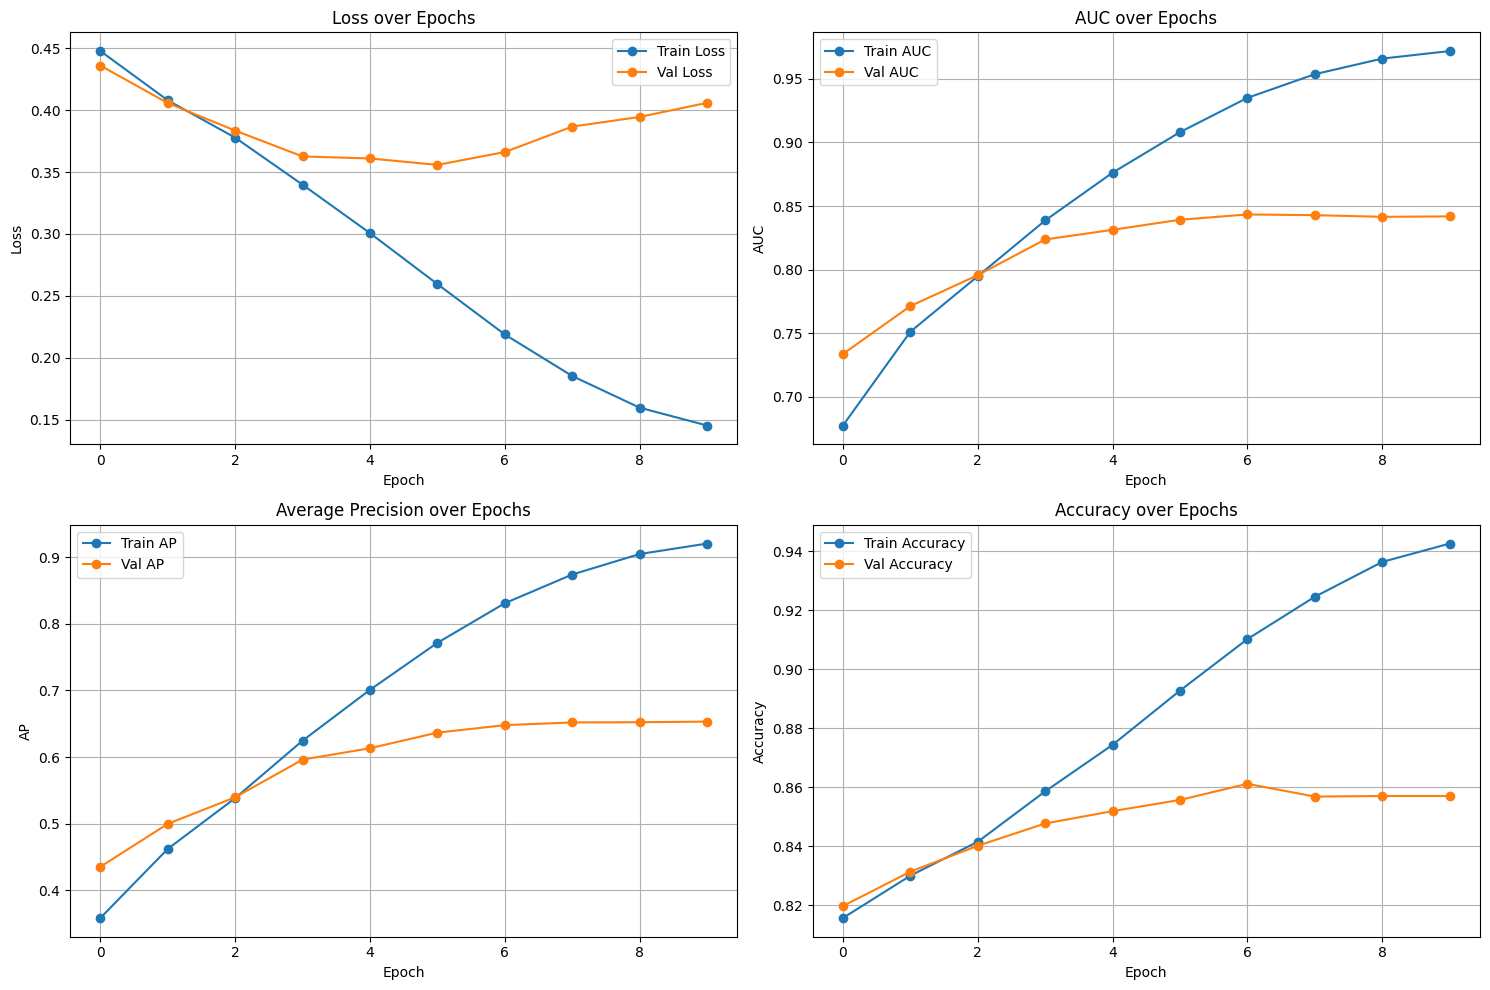


✓ Training history plot saved as 'training_history.png'


In [11]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='o')
axes[0, 0].set_title('Loss over Epochs')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# AUC
axes[0, 1].plot(history['train_auc'], label='Train AUC', marker='o')
axes[0, 1].plot(history['val_auc'], label='Val AUC', marker='o')
axes[0, 1].set_title('AUC over Epochs')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Average Precision
axes[1, 0].plot(history['train_ap'], label='Train AP', marker='o')
axes[1, 0].plot(history['val_ap'], label='Val AP', marker='o')
axes[1, 0].set_title('Average Precision over Epochs')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AP')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Accuracy
axes[1, 1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axes[1, 1].plot(history['val_acc'], label='Val Accuracy', marker='o')
axes[1, 1].set_title('Accuracy over Epochs')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Training history plot saved as 'training_history.png'")

In [12]:
from sklearn.metrics import f1_score, precision_score, recall_score

# ============================================================================
# EVALUATE ON VALIDATION SET WITH BEST MODEL
# ============================================================================

print("\n" + "="*70)
print("FINAL EVALUATION ON BEST MODEL")
print("="*70)

# Load best model
checkpoint = torch.load('best_vit_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
val_loss, val_preds, val_labels = validate_epoch(model, val_loader, criterion, device)
val_metrics = compute_metrics(val_labels, val_preds)

# Convert predictions to binary (threshold = 0.5)
val_preds_binary = (val_preds >= 0.5).astype(int)

print(f"\nOverall Metrics:")
print("-" * 70)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation AUC: {val_metrics['auc_mean']:.4f}")
print(f"Validation AP: {val_metrics['ap_mean']:.4f}")
print(f"Validation Accuracy: {val_metrics['accuracy']:.4f}")

# F1 Scores
f1_micro = f1_score(val_labels, val_preds_binary, average='micro')
f1_macro = f1_score(val_labels, val_preds_binary, average='macro')
f1_weighted = f1_score(val_labels, val_preds_binary, average='weighted')

print(f"\nF1 Scores:")
print(f"  F1 (Micro):    {f1_micro:.4f}")
print(f"  F1 (Macro):    {f1_macro:.4f}")
print(f"  F1 (Weighted): {f1_weighted:.4f}")

# Precision and Recall
precision_micro = precision_score(val_labels, val_preds_binary, average='micro')
precision_macro = precision_score(val_labels, val_preds_binary, average='macro')
recall_micro = recall_score(val_labels, val_preds_binary, average='micro')
recall_macro = recall_score(val_labels, val_preds_binary, average='macro')

print(f"\nPrecision & Recall:")
print(f"  Precision (Micro): {precision_micro:.4f}")
print(f"  Precision (Macro): {precision_macro:.4f}")
print(f"  Recall (Micro):    {recall_micro:.4f}")
print(f"  Recall (Macro):    {recall_macro:.4f}")

# Per-class metrics
print(f"\n{'='*70}")
print("PER-CLASS METRICS")
print("="*70)
print(f"{'Disease':<25} {'AUC':<8} {'AP':<8} {'F1':<8} {'Prec':<8} {'Recall':<8}")
print("-" * 70)

for i, label in enumerate(TARGET_LABELS):
    if len(np.unique(val_labels[:, i])) > 1:
        auc = roc_auc_score(val_labels[:, i], val_preds[:, i])
        ap = average_precision_score(val_labels[:, i], val_preds[:, i])
        f1 = f1_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        precision = precision_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        recall = recall_score(val_labels[:, i], val_preds_binary[:, i], zero_division=0)
        
        print(f"{label:<25} {auc:<8.4f} {ap:<8.4f} {f1:<8.4f} {precision:<8.4f} {recall:<8.4f}")
    else:
        print(f"{label:<25} {'N/A':<8} {'N/A':<8} {'N/A':<8} {'N/A':<8} {'N/A':<8}")

print("\n" + "="*70)
print("✓ Training and evaluation complete!")
print("="*70)


FINAL EVALUATION ON BEST MODEL
Loaded best model from epoch 7


Validation: 100%|██████████| 132/132 [00:47<00:00,  2.76it/s, loss=0.362] 


Overall Metrics:
----------------------------------------------------------------------
Validation Loss: 0.3662
Validation AUC: 0.8433
Validation AP: 0.6480
Validation Accuracy: 0.8612

F1 Scores:
  F1 (Micro):    0.5777
  F1 (Macro):    0.5559
  F1 (Weighted): 0.5615

Precision & Recall:
  Precision (Micro): 0.7149
  Precision (Macro): 0.6889
  Recall (Micro):    0.4847
  Recall (Macro):    0.4782

PER-CLASS METRICS
Disease                   AUC      AP       F1       Prec     Recall  
----------------------------------------------------------------------
Consolidation             0.8280   0.5815   0.5186   0.6216   0.4449  
Infiltration              0.7761   0.5357   0.4107   0.6313   0.3043  
Mass                      0.8537   0.6892   0.5875   0.7351   0.4892  
Nodule                    0.7983   0.5389   0.4298   0.6114   0.3314  
Pneumonia                 0.9606   0.8946   0.8328   0.8449   0.8210  

✓ Training and evaluation complete!


In [13]:
# ============================================================================
# FINAL TEST SET EVALUATION
# ============================================================================

print("\n" + "="*70)
print("FINAL TEST SET EVALUATION (UNSEEN DATA)")
print("="*70)

# Load best model
checkpoint = torch.load('best_vit_model.pth', weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate on TEST set (not validation!)
test_loss, test_preds, test_labels = validate_epoch(model, test_loader, criterion, device)
test_metrics = compute_metrics(test_labels, test_preds)

# Convert to binary
test_preds_binary = (test_preds >= 0.5).astype(int)

print(f"\nTest Set Metrics:")
print("-" * 70)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test AUC: {test_metrics['auc_mean']:.4f}")
print(f"Test AP: {test_metrics['ap_mean']:.4f}")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")

# F1 Scores
f1_micro = f1_score(test_labels, test_preds_binary, average='micro')
f1_macro = f1_score(test_labels, test_preds_binary, average='macro')

print(f"\nTest F1 Scores:")
print(f"  F1 (Micro): {f1_micro:.4f}")
print(f"  F1 (Macro): {f1_macro:.4f}")

# Per-class metrics
print(f"\nPer-class Test Metrics:")
print(f"{'Disease':<25} {'AUC':<8} {'AP':<8} {'F1':<8}")
print("-" * 70)
for i, label in enumerate(TARGET_LABELS):
    if len(np.unique(test_labels[:, i])) > 1:
        auc = roc_auc_score(test_labels[:, i], test_preds[:, i])
        ap = average_precision_score(test_labels[:, i], test_preds[:, i])
        f1 = f1_score(test_labels[:, i], test_preds_binary[:, i], zero_division=0)
        print(f"{label:<25} {auc:<8.4f} {ap:<8.4f} {f1:<8.4f}")


FINAL TEST SET EVALUATION (UNSEEN DATA)
Loaded best model from epoch 7


Validation: 100%|██████████| 132/132 [00:47<00:00,  2.76it/s, loss=0.618] 


Test Set Metrics:
----------------------------------------------------------------------
Test Loss: 0.3596
Test AUC: 0.8474
Test AP: 0.6572
Test Accuracy: 0.8634

Test F1 Scores:
  F1 (Micro): 0.5933
  F1 (Macro): 0.5743

Per-class Test Metrics:
Disease                   AUC      AP       F1      
----------------------------------------------------------------------
Consolidation             0.8343   0.5839   0.5149  
Infiltration              0.7807   0.5600   0.4468  
Mass                      0.8593   0.7115   0.6195  
Nodule                    0.8045   0.5285   0.4441  
Pneumonia                 0.9582   0.9021   0.8460  
